# K-Means Clustring and Feature Space Visualizaiton

## Imports and Paths

In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

from src.data_utils import load_tabular_features, make_class_mappings

ROOT = Path.cwd().parent.resolve()

FEATURE_DIR = ROOT / "data/features"
FIGURE_DIR = ROOT / "figures"
RESULTS_DIR = ROOT / "results/clustring"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATH = FEATURE_DIR / "tabular_audio_features.npz"

SEED = 42

print("Feature path:", FEATURE_PATH)
print("Results dir:", RESULTS_DIR)
print("Figures dir:", FIGURE_DIR)

Feature path: D:\Projects\Audio\Audio Pattern Recognition\data\features\tabular_audio_features.npz
Results dir: D:\Projects\Audio\Audio Pattern Recognition\results\clustring
Figures dir: D:\Projects\Audio\Audio Pattern Recognition\figures


## Loading Tabular Audio Features

In [3]:
data = load_tabular_features(FEATURE_PATH)

X = data["X"]
y = data["y"]
labels = data["labels"]
folds = data["folds"]
filenames = data["filenames"]
feature_names = data["feature_names"]

print("X:", X.shape)
print("y:", y.shape)
print("labels:", labels.shape)
print("folds:", folds.shape)
print("Number of features:", len(feature_names))

X: (8732, 176)
y: (8732,)
labels: (8732,)
folds: (8732,)
Number of features: 176


In [5]:
class_table, class_ids, class_names, id_to_class = make_class_mappings(y, labels)

display(class_table)

class_order = class_names.tolist()
class_order

,class_id,class
0,0,air_conditioner
1,1,car_horn
2,2,children_playing
3,3,dog_bark
4,4,drilling
5,5,engine_idling
6,6,gun_shot
7,7,jackhammer
8,8,siren
9,9,street_music


['air_conditioner',
 'car_horn',
 'children_playing',
 'dog_bark',
 'drilling',
 'engine_idling',
 'gun_shot',
 'jackhammer',
 'siren',
 'street_music']

## Standardize Features

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling:", np.mean(X_scaled).round(4))
print("Std after scaling:", np.std(X_scaled).round(4))

Mean after scaling: 0.0
Std after scaling: 1.0


## K-Means Clustring

In [7]:
N_CLUSTERS = 10

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster labels:", cluster_labels.shape)
print("Cluster counts:")
display(pd.Series(cluster_labels).value_counts().sort_index().to_frame("count"))

Cluster labels: (8732,)
Cluster counts:


,count
0,571
1,548
2,1263
3,1292
4,118
5,1578
6,1310
7,775
8,1176
9,101


## Clustring Metrics

In [8]:
ari = adjusted_rand_score(y, cluster_labels)  # Higher is better
nmi = normalized_mutual_info_score(y, cluster_labels)  # Higher is better
sil = silhouette_score(X_scaled, cluster_labels)  # Higher is better

clustering_metrics = {
    "n_clusters": int(N_CLUSTERS),
    "adjusted_rand_index": float(ari),
    "normalized_mutual_information": float(nmi),
    "silhouette_score": float(sil),
}

clustering_metrics

{'n_clusters': 10,
 'adjusted_rand_index': 0.1691544337005088,
 'normalized_mutual_information': 0.30947047908558023,
 'silhouette_score': 0.08617069572210312}

## Cluster-Class Relationship

In [9]:
cluster_class_table = pd.crosstab(
    pd.Series(cluster_labels, name="cluster"), pd.Series(labels, name="true_class")
)

display(cluster_class_table)

true_class,air_conditioner,car_horn,children_playing,dog_bark,drilling,engine_idling,gun_shot,jackhammer,siren,street_music
cluster,,,,,,,,,,
0,4,2,117,57,25,37,0,9,119,201
1,7,6,44,422,14,0,10,0,42,3
2,172,12,33,19,528,99,0,385,11,4
3,53,42,398,102,37,31,0,1,201,427
4,0,0,1,6,0,0,0,0,94,17
5,312,68,43,45,177,308,1,371,168,85
6,448,9,83,52,43,489,0,52,79,55
7,0,5,275,76,7,0,0,0,204,208
8,4,184,6,221,169,36,363,182,11,0


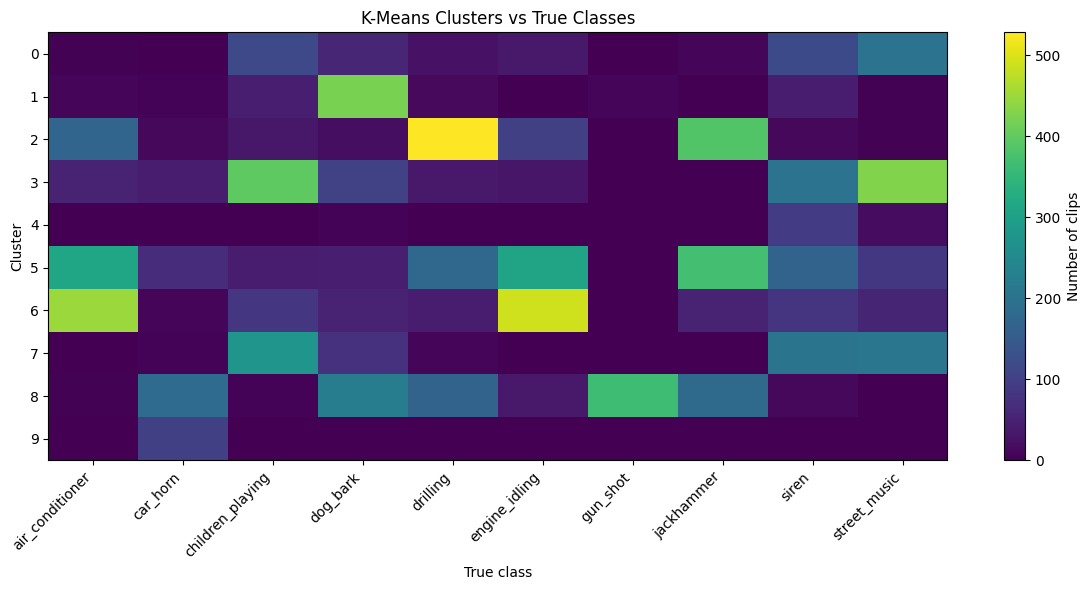

Saved: D:\Projects\Audio\Audio Pattern Recognition\figures\kmeans_cluster_class_heatmap.png


In [10]:
plt.figure(figsize=(12, 6))
plt.imshow(cluster_class_table.values, aspect="auto")
plt.colorbar(label="Number of clips")
plt.title("K-Means Clusters vs True Classes")
plt.xlabel("True class")
plt.ylabel("Cluster")
plt.xticks(
    range(len(cluster_class_table.columns)),
    cluster_class_table.columns,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(cluster_class_table.index)), cluster_class_table.index)
plt.tight_layout()

cluster_heatmap_path = FIGURE_DIR / "kmeans_cluster_class_heatmap.png"
plt.savefig(cluster_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cluster_heatmap_path)

## PCA Visualization

In [11]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA shape: (8732, 2)
Explained variance ratio: [0.30336115 0.08187345]
Total explained variance: 0.3852346


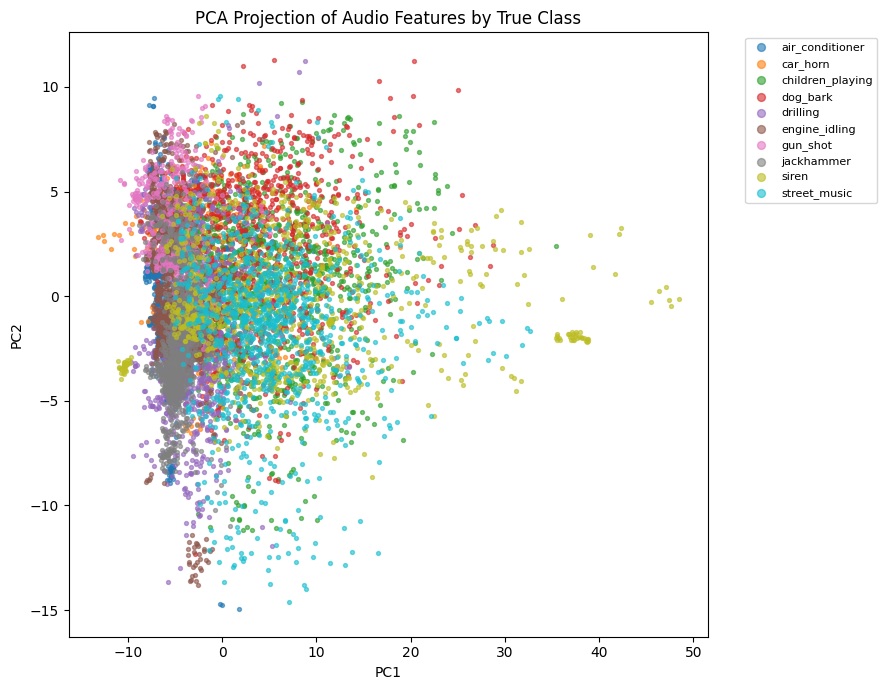

Saved: D:\Projects\Audio\Audio Pattern Recognition\figures\pca_true_classes.png


In [12]:
plt.figure(figsize=(9, 7))

for class_id in sorted(np.unique(y)):
    idx = y == class_id
    plt.scatter(
        X_pca[idx, 0], X_pca[idx, 1], s=8, alpha=0.6, label=id_to_class[class_id]
    )

plt.title("PCA Projection of Audio Features by True Class")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

pca_true_path = FIGURE_DIR / "pca_true_classes.png"
plt.savefig(pca_true_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pca_true_path)

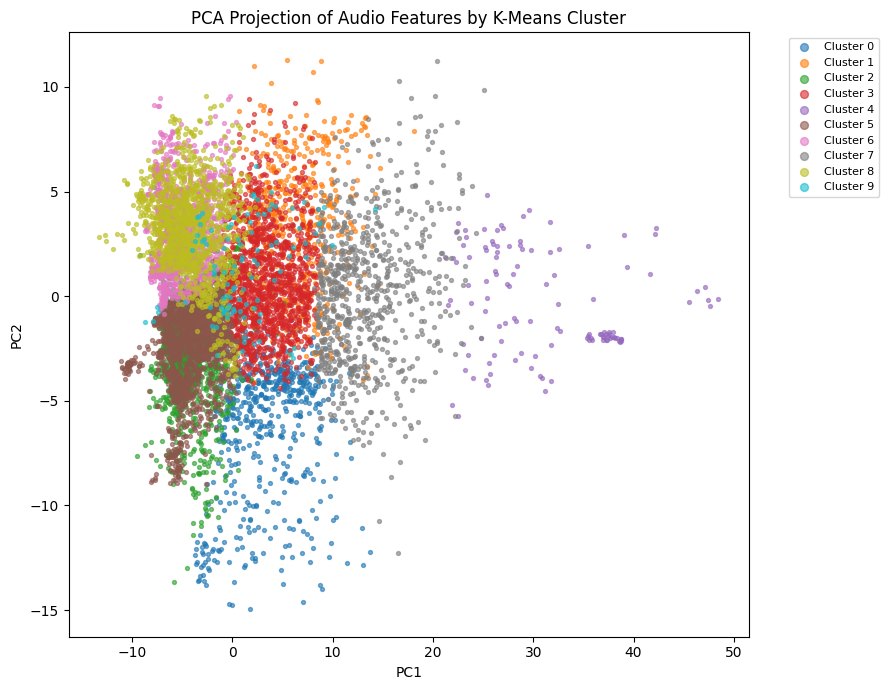

Saved: D:\Projects\Audio\Audio Pattern Recognition\figures\pca_kmeans_clusters.png


In [13]:
plt.figure(figsize=(9, 7))

for cluster_id in sorted(np.unique(cluster_labels)):
    idx = cluster_labels == cluster_id
    plt.scatter(
        X_pca[idx, 0], X_pca[idx, 1], s=8, alpha=0.6, label=f"Cluster {cluster_id}"
    )

plt.title("PCA Projection of Audio Features by K-Means Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

pca_cluster_path = FIGURE_DIR / "pca_kmeans_clusters.png"
plt.savefig(pca_cluster_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pca_cluster_path)

## t-SNE Visualization

In [20]:
pca_50 = PCA(n_components=50, random_state=SEED)
X_pca_50 = pca_50.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)

X_tsne = tsne.fit_transform(X_pca_50)

print("t-SNE shape:", X_tsne.shape)

t-SNE shape: (8732, 2)


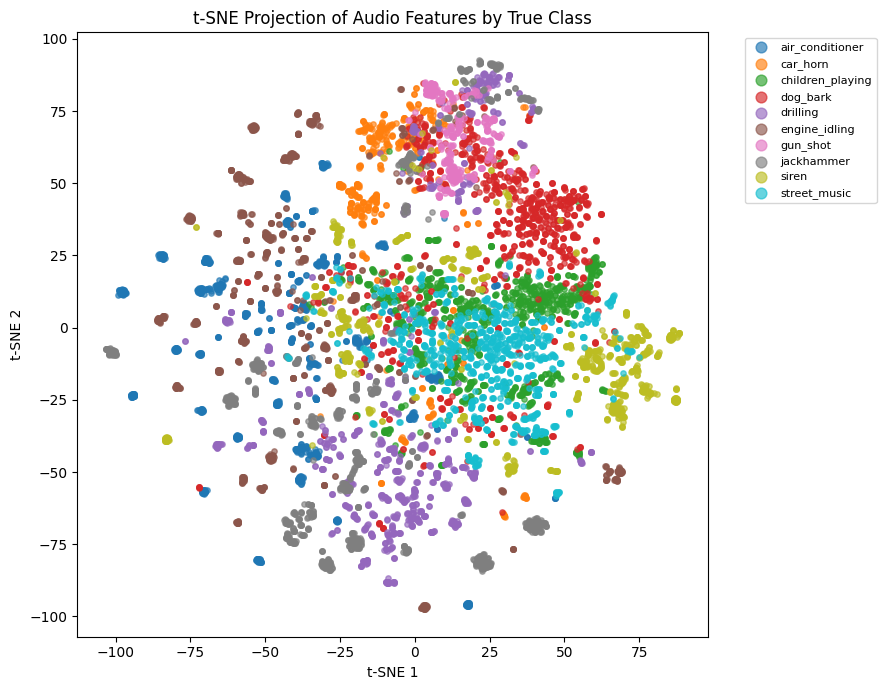

Saved: D:\Projects\Audio\Audio Pattern Recognition\figures\tsne_true_classes.png


In [21]:
plt.figure(figsize=(9, 7))

for class_id in sorted(np.unique(y)):
    idx = y == class_id
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        s=15,
        alpha=0.65,
        label=id_to_class[class_id]
    )

plt.title("t-SNE Projection of Audio Features by True Class")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

tsne_true_path = FIGURE_DIR / "tsne_true_classes.png"
plt.savefig(tsne_true_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", tsne_true_path)

## Saving Clustering Outputs

In [22]:
np.savez_compressed(
    RESULTS_DIR / "kmeans_results.npz",
    cluster_labels=cluster_labels,
    X_pca=X_pca,
    X_tsne=X_tsne,
    y=y,
    labels=labels,
    folds=folds,
    filenames=filenames
)

with open(RESULTS_DIR / "kmeans_metrics.json", "w") as f:
    json.dump(clustering_metrics, f, indent=4)

cluster_class_table.to_csv(RESULTS_DIR / "cluster_class_table.csv")

print("Saved:")
print(RESULTS_DIR / "kmeans_results.npz")
print(RESULTS_DIR / "kmeans_metrics.json")
print(RESULTS_DIR / "cluster_class_table.csv")

Saved:
D:\Projects\Audio\Audio Pattern Recognition\results\clustring\kmeans_results.npz
D:\Projects\Audio\Audio Pattern Recognition\results\clustring\kmeans_metrics.json
D:\Projects\Audio\Audio Pattern Recognition\results\clustring\cluster_class_table.csv
